# R Language Guide — Part 2: Data Visualization & Variability

This notebook covers:
1. **Base R Plots** — pie charts, barplots
2. **ggplot2 Basics** — bar charts, histograms, boxplots, line plots
3. **Advanced ggplot2** — stacked/dodged/filled bars, multi-group boxplots, time series
4. **Variability Indexes** — range, IQR, variance, standard deviation, coefficient of variation
5. **Gini Index** — concentration measure for categorical variables
6. **dplyr** — grouped summaries with pipes
7. **Maps** — plotting geographic data

---
## 1. BASE R PLOTS

First, let's load the tonni (tuna) dataset and compute frequency distributions.

In [1]:
# Load data
dati <- read.csv("tonni.csv", sep = ";")
N <- dim(dati)[1]

# Create classes for LUNGHEZZA
dati$LUNGHEZZA_CL <- cut(
  dati$LUNGHEZZA,
  breaks = c(10, 15, 20, 25, 30)
)

# Frequency distribution
ni <- table(dati$LUNGHEZZA_CL)
fi <- table(dati$LUNGHEZZA_CL) / N
Ni <- cumsum(ni)
Fi <- Ni / N

distr_freq_lung <- as.data.frame(cbind(ni, fi, Ni, Fi))
print(distr_freq_lung)

        ni   fi Ni   Fi
(10,15]  7 0.35  7 0.35
(15,20]  8 0.40 15 0.75
(20,25]  4 0.20 19 0.95
(25,30]  1 0.05 20 1.00


In [2]:
? as.data.frame()

as.data.frame               package:base               R Documentation

_C_o_e_r_c_e _t_o _a _D_a_t_a _F_r_a_m_e

_D_e_s_c_r_i_p_t_i_o_n:

     Functions to check if an object is a data frame, or coerce it if
     possible.

_U_s_a_g_e:

     as.data.frame(x, row.names = NULL, optional = FALSE, ...)
     
     ## S3 method for class 'character'
     as.data.frame(x, ...,
                   stringsAsFactors = FALSE)
     
     ## S3 method for class 'list'
     as.data.frame(x, row.names = NULL, optional = FALSE, ...,
                   cut.names = FALSE, col.names = names(x), fix.empty.names = TRUE,
                   new.names = !missing(col.names),
                   check.names = !optional,
                   stringsAsFactors = FALSE)
     
     ## S3 method for class 'matrix'
     as.data.frame(x, row.names = NULL, optional = FALSE,
                   make.names = TRUE, ...,
                   stringsAsFactors = FALSE)
     
     as.data.frame.vect

### 1.1 Pie Charts

Pie charts are generally **not recommended** for statistical visualization,  
but here's how to create them in base R.

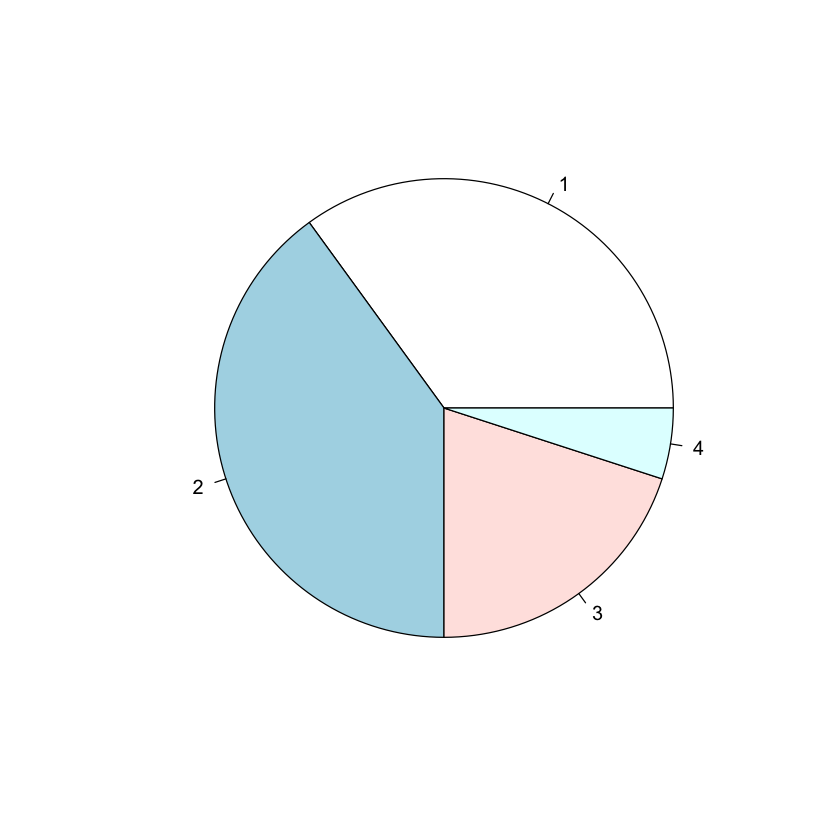

In [3]:
# Basic pie chart (no labels, no colors)
pie(distr_freq_lung$fi)

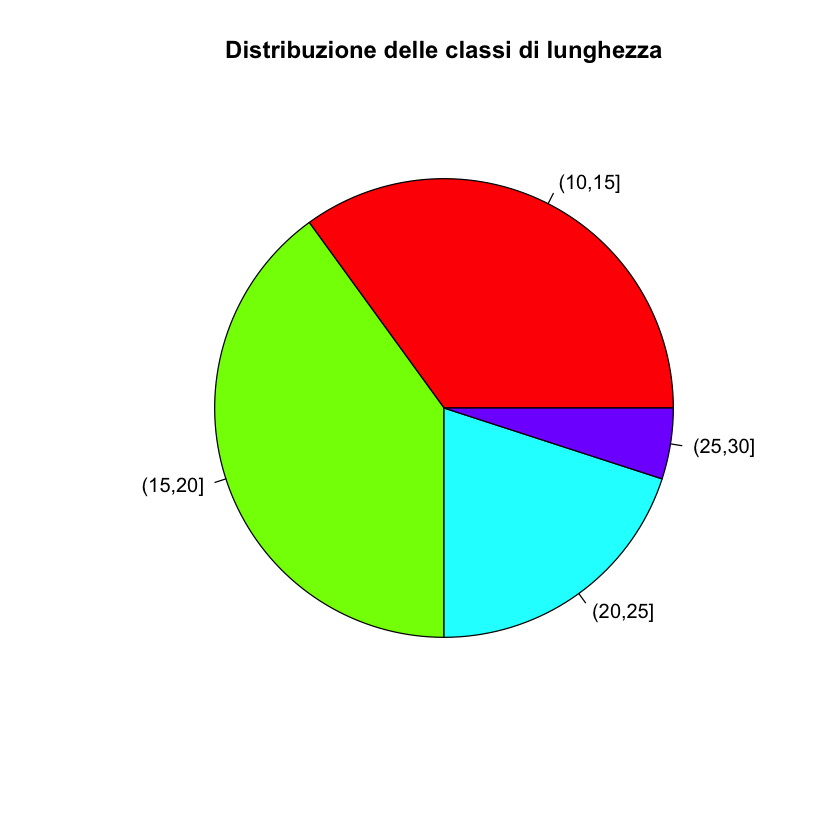

In [4]:
# Better pie chart with title, colors, and labels
pie(distr_freq_lung$fi, 
    main = "Distribuzione delle classi di lunghezza",
    col = rainbow(length(distr_freq_lung$fi)),
    labels = rownames(distr_freq_lung))

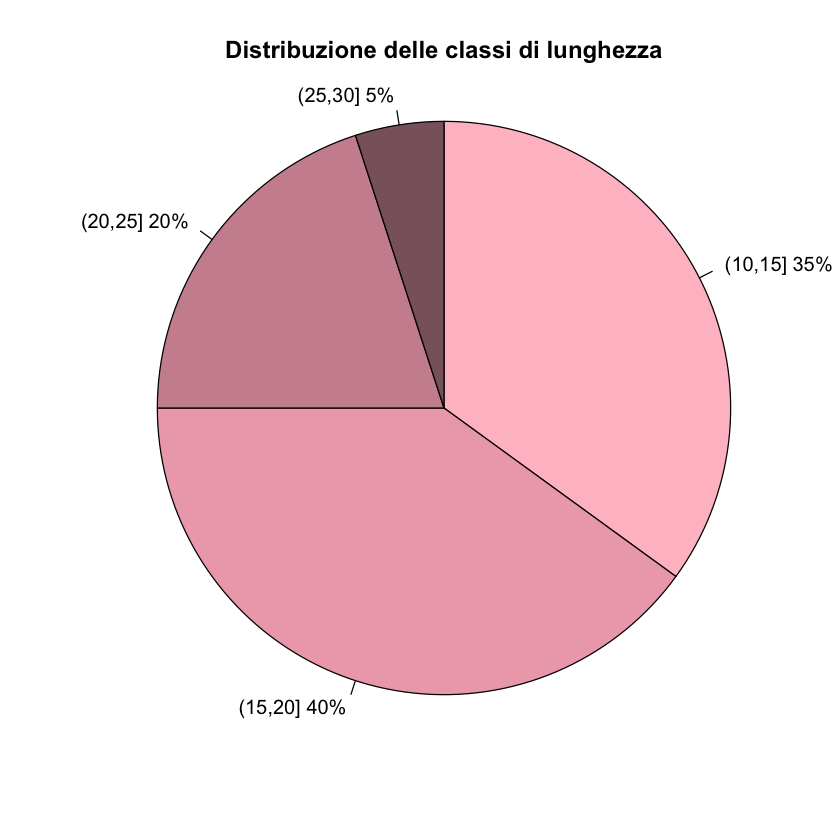

In [5]:
# Pie chart with percentage labels and custom colors
labels <- paste(rownames(distr_freq_lung), " ", distr_freq_lung$fi * 100, "%", sep = "")
colors <- c("pink", "pink2", "pink3", "pink4")

pie(distr_freq_lung$fi, 
    main = "Distribuzione delle classi di lunghezza",
    col = colors,
    labels = labels,
    radius = 1,
    clockwise = TRUE)

### 1.2 Barplots (Base R)

Barplots are a better alternative to pie charts for frequency data.

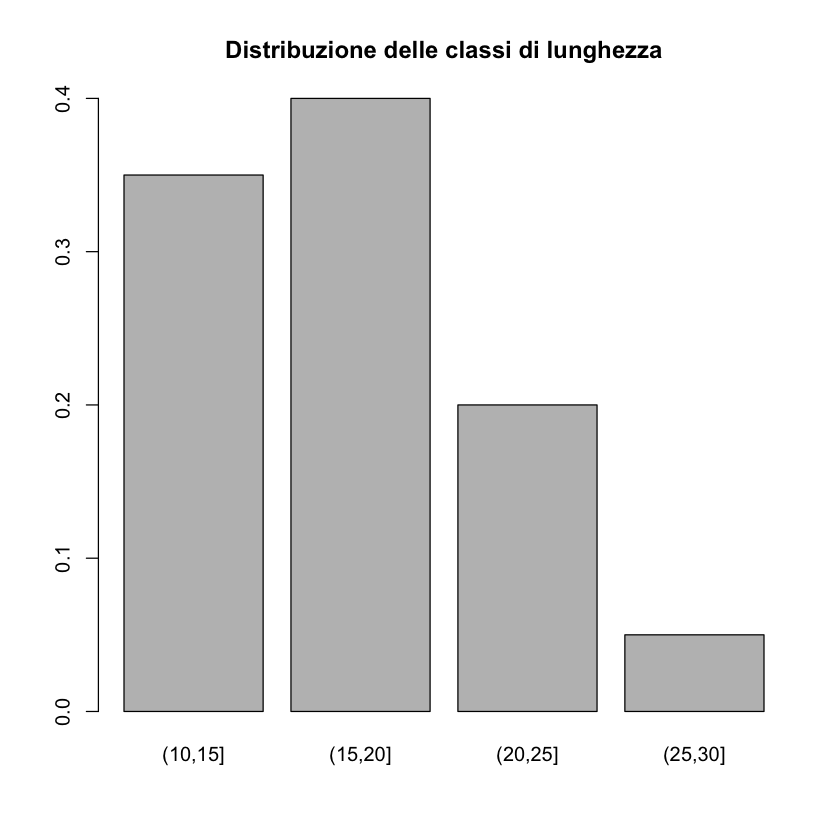

In [6]:
# Basic barplot
barplot(distr_freq_lung$fi, 
        main = "Distribuzione delle classi di lunghezza",
        names.arg = rownames(distr_freq_lung))

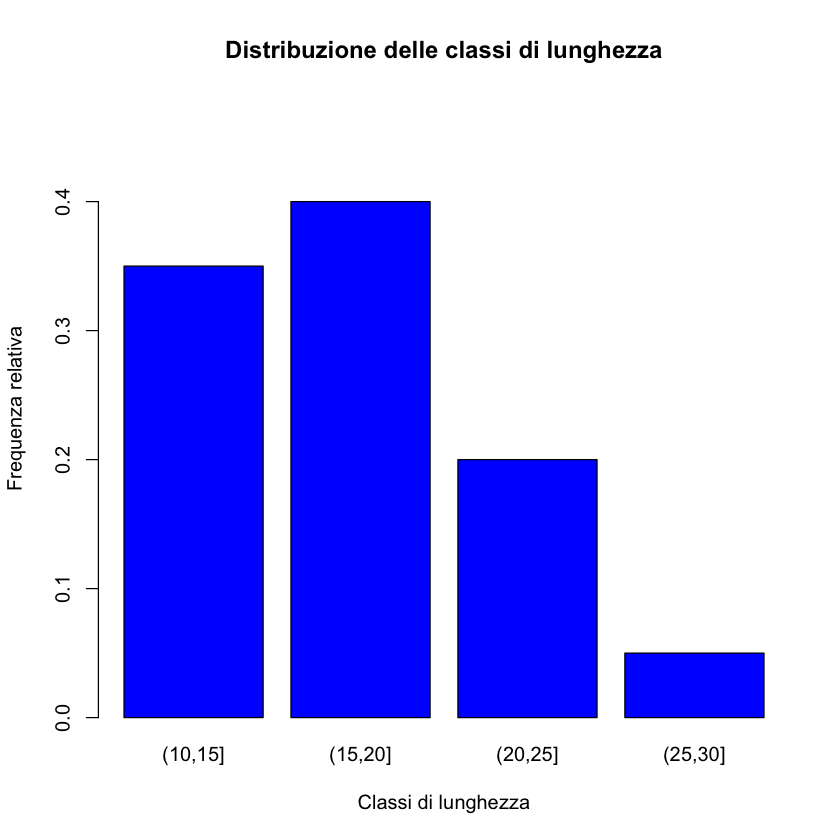

In [7]:
# Better barplot with axis labels and y-axis limits
barplot(distr_freq_lung$fi, 
        main = "Distribuzione delle classi di lunghezza",
        names.arg = rownames(distr_freq_lung),
        xlab = "Classi di lunghezza",
        ylab = "Frequenza relativa",
        ylim = c(0, max(distr_freq_lung$fi) * 1.2),
        col = "blue")

---
## 2. GGPLOT2 — THE GRAMMAR OF GRAPHICS

`ggplot2` is the most popular R package for data visualization.  
It uses a layered approach: data → aesthetics → geometries → scales → themes.

In [8]:
library(ggplot2)

### 2.1 Bar Charts with ggplot2

`geom_bar()` with `stat = "count"` creates bar charts from raw data.

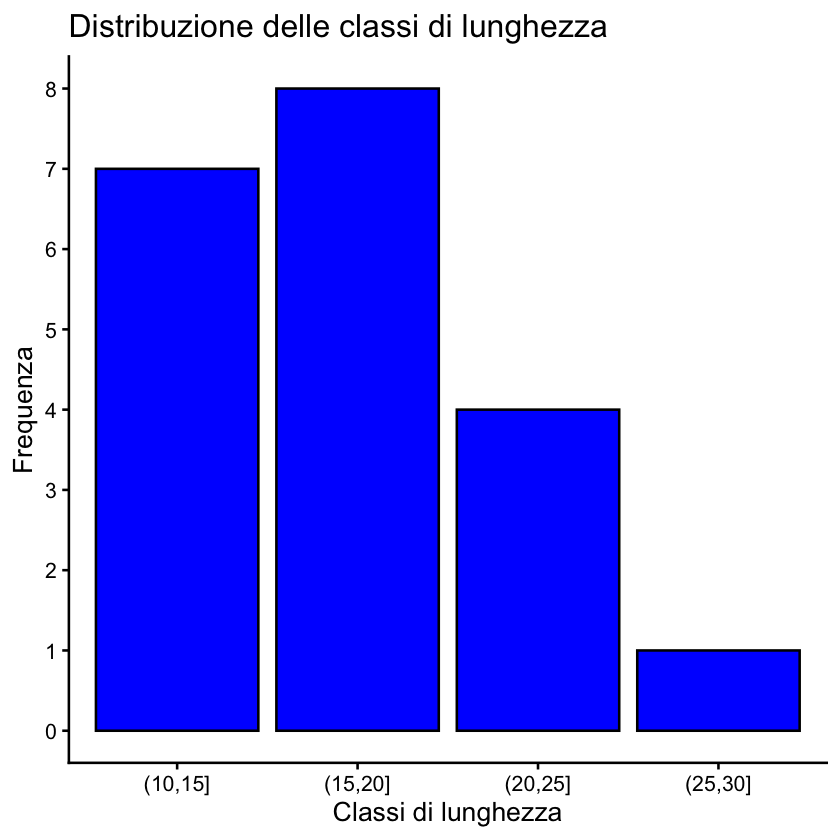

In [9]:
# Simple bar chart of length classes
p <- ggplot(data = dati) +
  geom_bar(aes(x = LUNGHEZZA_CL), stat = "count", color = "black", fill = "blue") +
  labs(title = "Distribuzione delle classi di lunghezza", 
       x = "Classi di lunghezza", 
       y = "Frequenza") +
  scale_y_continuous(breaks = seq(0, 8, 1)) +
  theme_classic(base_size = 16)
print(p)

### 2.2 Stacked Bar Charts

By moving `fill` inside `aes()`, you can color bars by a second variable.

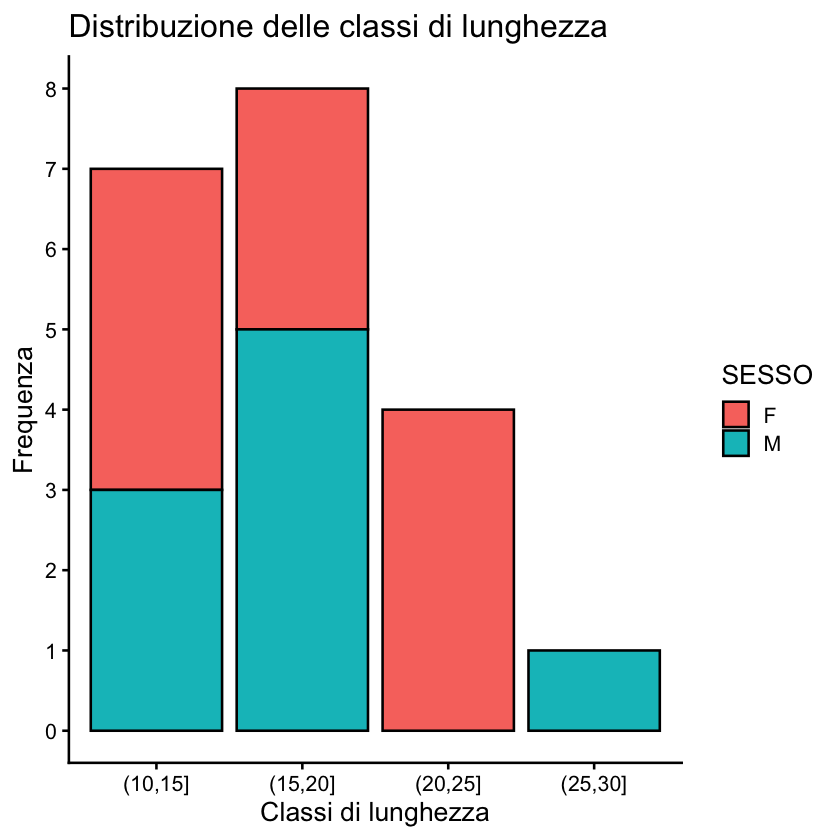

In [10]:
# Stacked bar chart by SESSO
p <- ggplot(data = dati) +
  geom_bar(aes(x = LUNGHEZZA_CL,
               fill = SESSO), 
           stat = "count", 
           color = "black",
           position = "stack") +
  labs(title = "Distribuzione delle classi di lunghezza", 
       x = "Classi di lunghezza", 
       y = "Frequenza") +
  scale_y_continuous(breaks = seq(0, 8, 1)) +
  theme_classic(base_size = 16)
print(p)

### 2.3 Dodged (Side-by-Side) Bar Charts

Use `position = "dodge"` to place bars side by side.

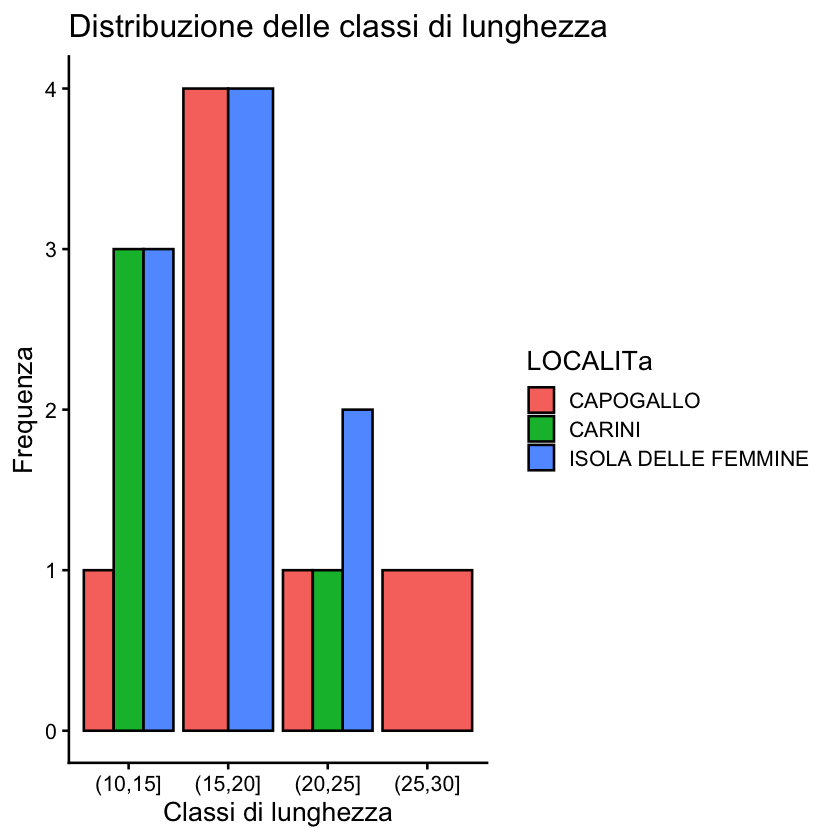

In [11]:
# Dodged bar chart by LOCALITA
p <- ggplot(data = dati) +
  geom_bar(aes(x = LUNGHEZZA_CL,
               fill = LOCALITa), 
           stat = "count", 
           color = "black",
           position = "dodge") +
  labs(title = "Distribuzione delle classi di lunghezza", 
       x = "Classi di lunghezza", 
       y = "Frequenza") +
  scale_y_continuous(breaks = seq(0, 8, 1)) +
  theme(legend.position = "bottom") +
  theme_classic(base_size = 16)
print(p)

### 2.4 Filled Bar Charts (Proportions)

Use `position = "fill"` to show proportions instead of counts.

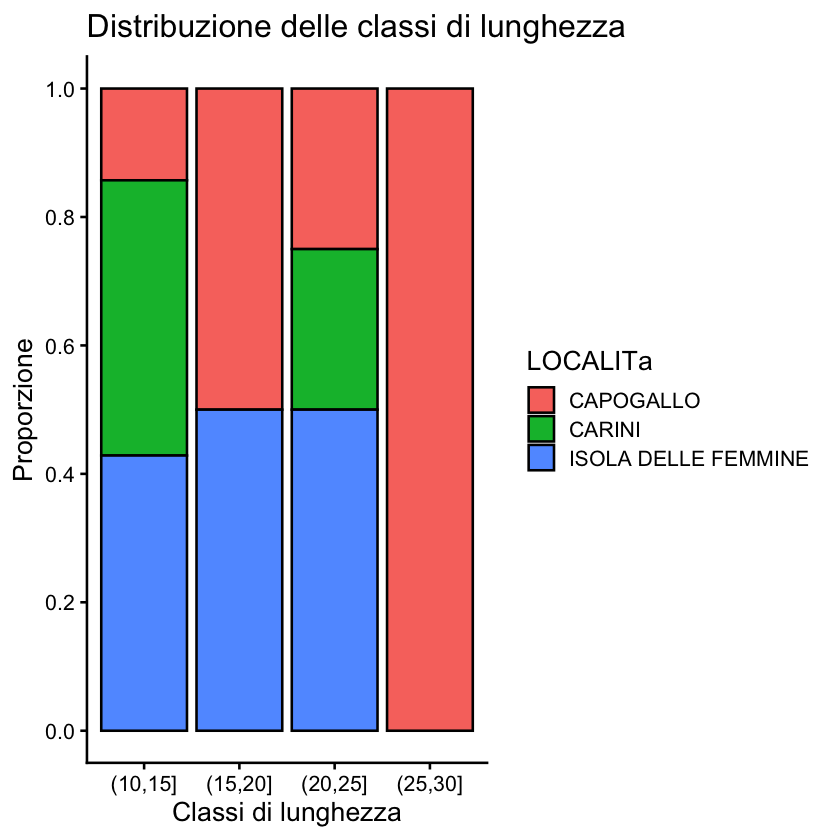

In [12]:
# Filled bar chart (proportions) by LOCALITA
p <- ggplot(data = dati) +
  geom_bar(aes(x = LUNGHEZZA_CL,
               fill = LOCALITa), 
           stat = "count", 
           color = "black",
           position = "fill") +
  labs(title = "Distribuzione delle classi di lunghezza", 
       x = "Classi di lunghezza", 
       y = "Proporzione") +
  scale_y_continuous(breaks = seq(0, 1, 0.2)) +
  theme(legend.position = "bottom") +
  theme_classic(base_size = 16)
print(p)

---
## 3. TIME SERIES PLOTS

Let's load the births/deaths dataset and create line plots.

In [13]:
# Load nascite e morti (births and deaths) dataset
dati_ts <- read.csv("nascite e morti.csv", sep = ",")
str(dati_ts)

'data.frame':	21 obs. of  4 variables:
 $ X      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ tempo  : int  2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 ...
 $ nascite: int  991 1016 1028 1007 1001 1020 1041 1006 987 1002 ...
 $ morti  : int  952 972 978 1010 993 1030 996 1058 1032 989 ...


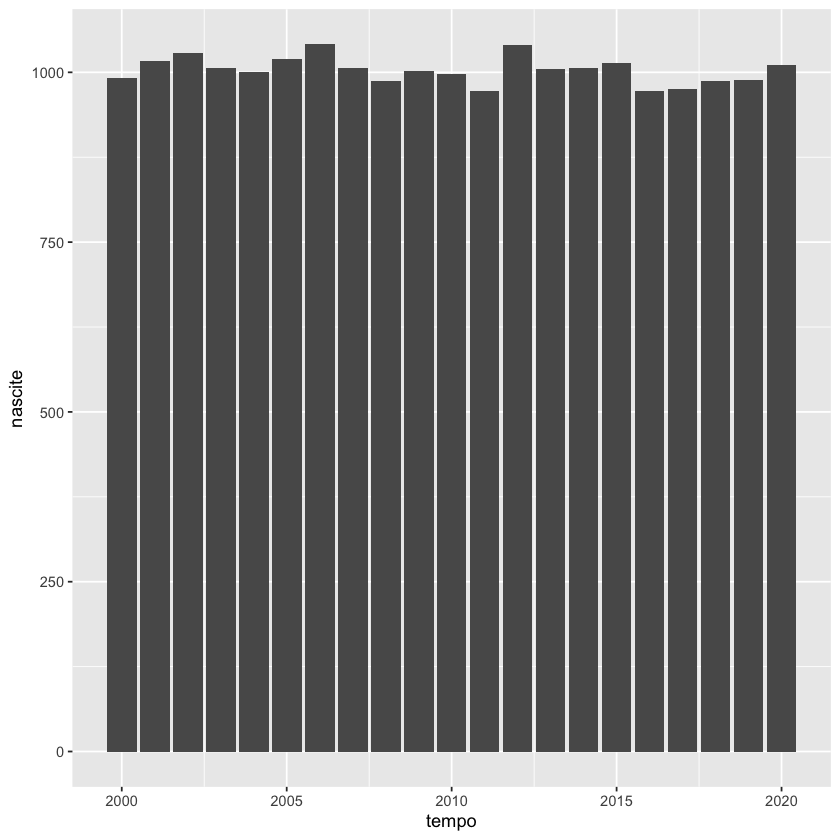

In [14]:
# Simple column chart
p <- ggplot(data = dati_ts) +
    geom_col(aes(x = tempo, y = nascite))
print(p)

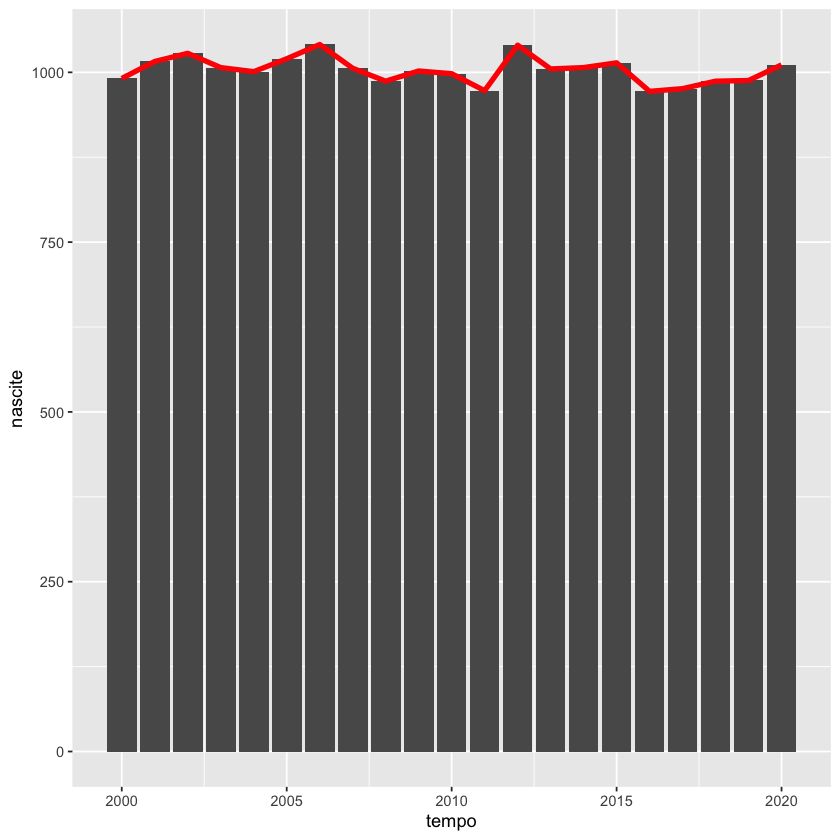

In [15]:
# Add a line on top of the bars
p <- ggplot(data = dati_ts) +
    geom_col(aes(x = tempo, y = nascite)) +
    geom_line(aes(x = tempo, y = nascite), color = "red", lwd = 1.5)
print(p)

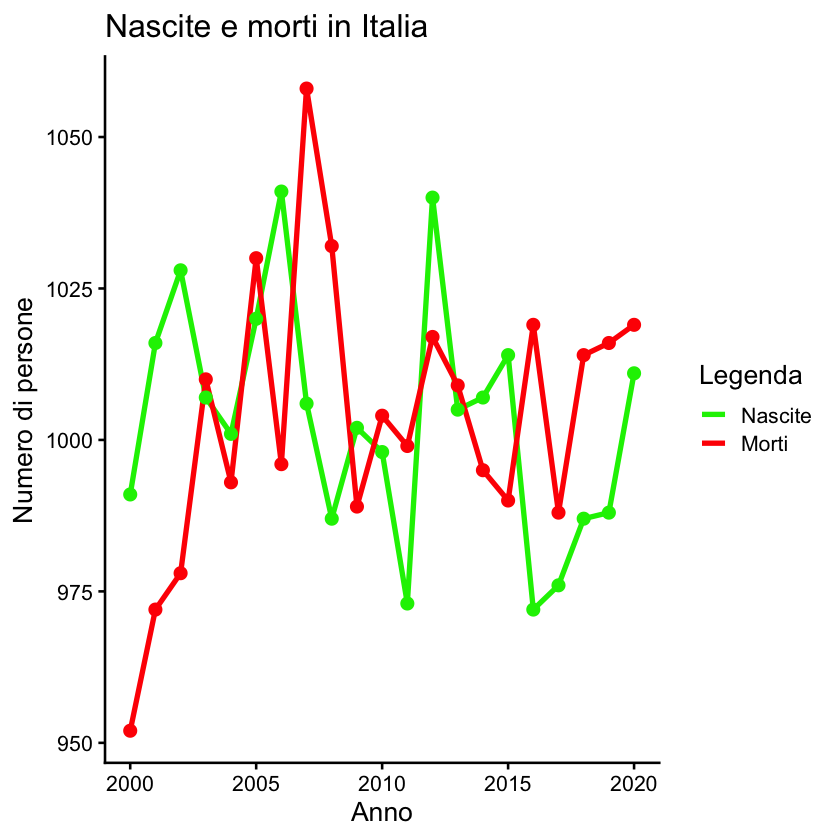

In [16]:
# Dual line plot: births vs deaths with legend
p <- ggplot(data = dati_ts) +
    geom_line(aes(x = tempo, y = nascite, color = "Nascite"), lwd = 1.5) +
    geom_line(aes(x = tempo, y = morti, color = "Morti"), lwd = 1.5) + 
    geom_point(aes(x = tempo, y = nascite), color = "green2", size = 3) +
    geom_point(aes(x = tempo, y = morti), color = "red", size = 3) +
    labs(title = "Nascite e morti in Italia", x = "Anno", y = "Numero di persone") +
    scale_color_manual(name = "Legenda", 
                        values = c("Nascite" = "green2", "Morti" = "red"), 
                        breaks = c("Nascite", "Morti")) +
    theme_classic(base_size = 16)
print(p)

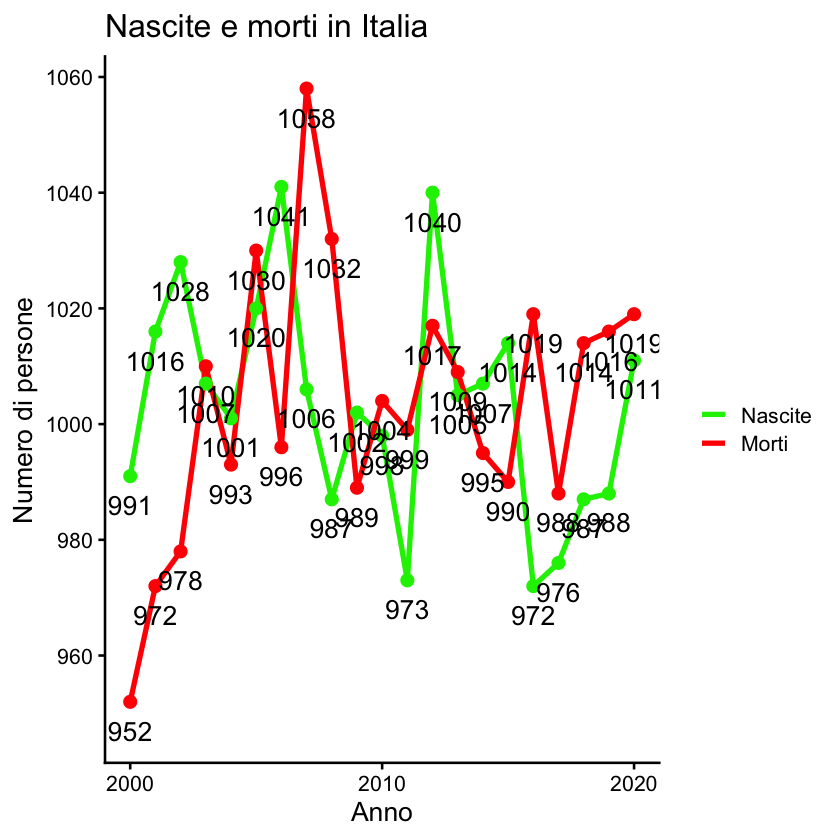

In [17]:
# Enhanced version with data labels and custom x-axis breaks
p <- ggplot(data = dati_ts) +
    geom_line(aes(x = tempo, y = nascite, color = "Nascite"), lwd = 1.5) +
    geom_line(aes(x = tempo, y = morti, color = "Morti"), lwd = 1.5) + 
    geom_point(aes(x = tempo, y = nascite), color = "green2", size = 3) +
    geom_point(aes(x = tempo, y = morti), color = "red", size = 3) +
    labs(title = "Nascite e morti in Italia", x = "Anno", y = "Numero di persone") +
    scale_color_manual(name = "", values = c("Nascite" = "green2", "Morti" = "red"), 
                        breaks = c("Nascite", "Morti")) +
    geom_text(aes(x = tempo, y = nascite - 5, label = nascite)) +
    geom_text(aes(x = tempo, y = morti - 5, label = morti)) +
    scale_x_continuous(breaks = seq(2000, 2020, 10)) +
    theme_classic(base_size = 16)
print(p)

---
## 4. BOXPLOTS & VARIABILITY (diamonds dataset)

Let's use the built-in `diamonds` dataset from ggplot2.

In [18]:
library(ggplot2)
data("diamonds")
head(diamonds)
summary(diamonds)

carat,cut,color,clarity,depth,table,price,x,y,z
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63
0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
0.24,Very Good,J,VVS2,62.8,57,336,3.94,3.96,2.48


     carat               cut        color        clarity          depth      
 Min.   :0.2000   Fair     : 1610   D: 6775   SI1    :13065   Min.   :43.00  
 1st Qu.:0.4000   Good     : 4906   E: 9797   VS2    :12258   1st Qu.:61.00  
 Median :0.7000   Very Good:12082   F: 9542   SI2    : 9194   Median :61.80  
 Mean   :0.7979   Premium  :13791   G:11292   VS1    : 8171   Mean   :61.75  
 3rd Qu.:1.0400   Ideal    :21551   H: 8304   VVS2   : 5066   3rd Qu.:62.50  
 Max.   :5.0100                     I: 5422   VVS1   : 3655   Max.   :79.00  
                                    J: 2808   (Other): 2531                  
     table           price             x                y         
 Min.   :43.00   Min.   :  326   Min.   : 0.000   Min.   : 0.000  
 1st Qu.:56.00   1st Qu.:  950   1st Qu.: 4.710   1st Qu.: 4.720  
 Median :57.00   Median : 2401   Median : 5.700   Median : 5.710  
 Mean   :57.46   Mean   : 3933   Mean   : 5.731   Mean   : 5.735  
 3rd Qu.:59.00   3rd Qu.: 5324   3rd Qu.:

In [20]:
# Attach for direct column access
attach(diamonds)

# Summary of price
summary(price)

The following objects are masked from diamonds (pos = 3):

    carat, clarity, color, cut, depth, price, table, x, y, z




   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    326     950    2401    3933    5324   18823 

### 4.1 Range and Interquartile Range

In [21]:
# Range
max(price); min(price); max(price) - min(price)  # the range
range(price)

# Interquartile Range
IQR(price)

[1] 18823

[1] 326

[1] 18497

[1]   326 18823

[1] 4374.25

### 4.2 Scatter Plot with Quantile Lines

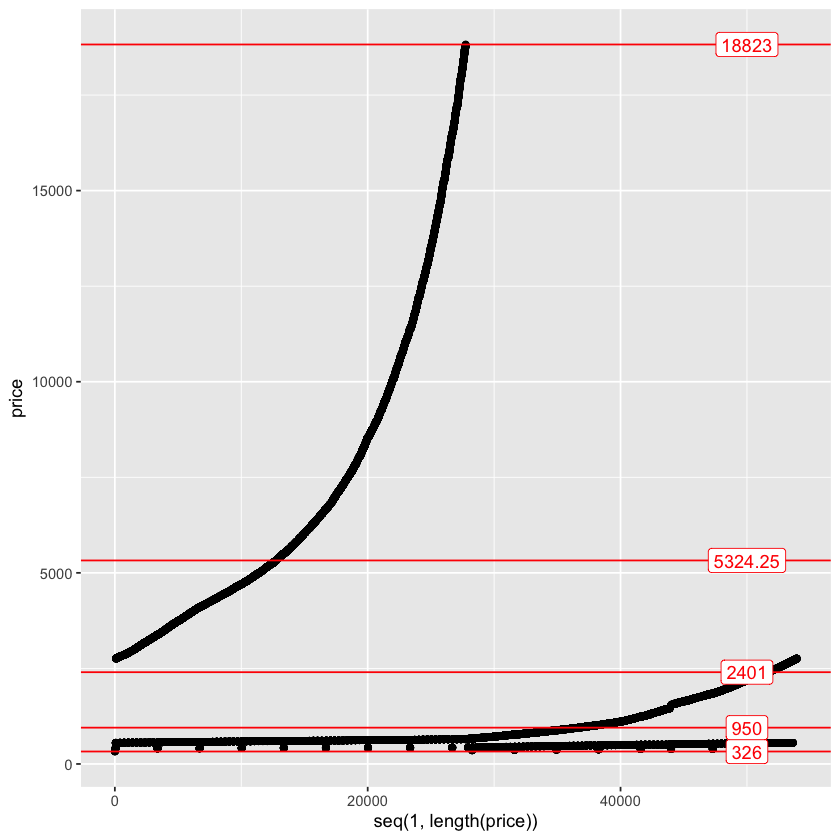

In [22]:
# Scatter plot of price with quantile reference lines
ggplot() +
  geom_point(aes(x = seq(1, length(price)), y = price)) +
  geom_hline(yintercept = quantile(price), color = "red") +
  geom_label(aes(x = 50000, y = quantile(price)), label = quantile(price), color = "red")

### 4.3 Boxplots

Boxplots are the best way to visualize the distribution of a numeric variable.

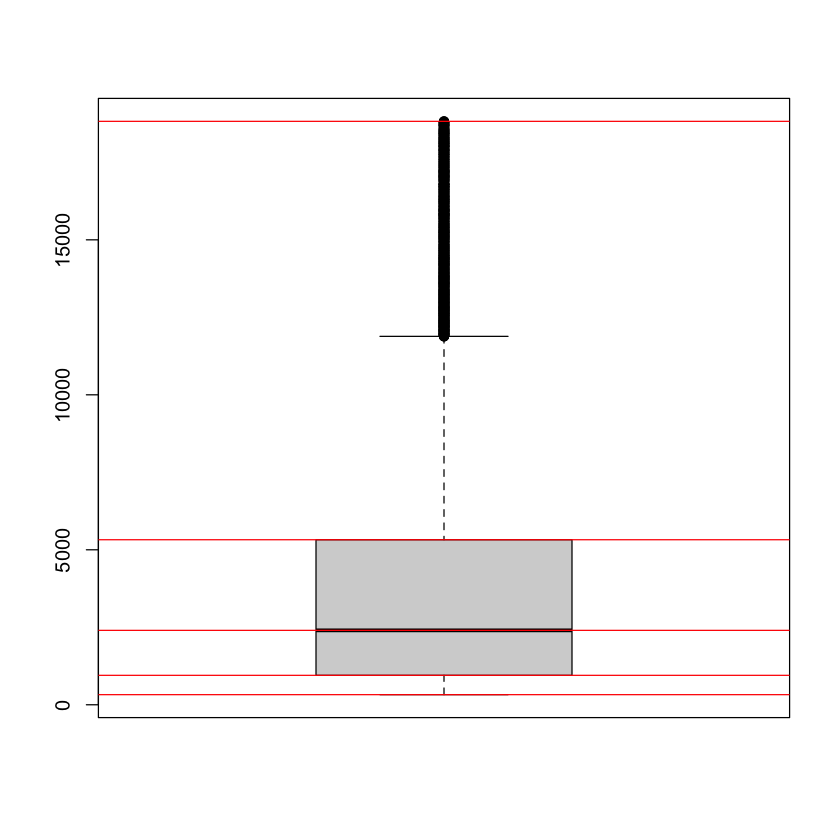

In [23]:
# Base R boxplot
boxplot(price)
abline(h = quantile(price), col = "red")

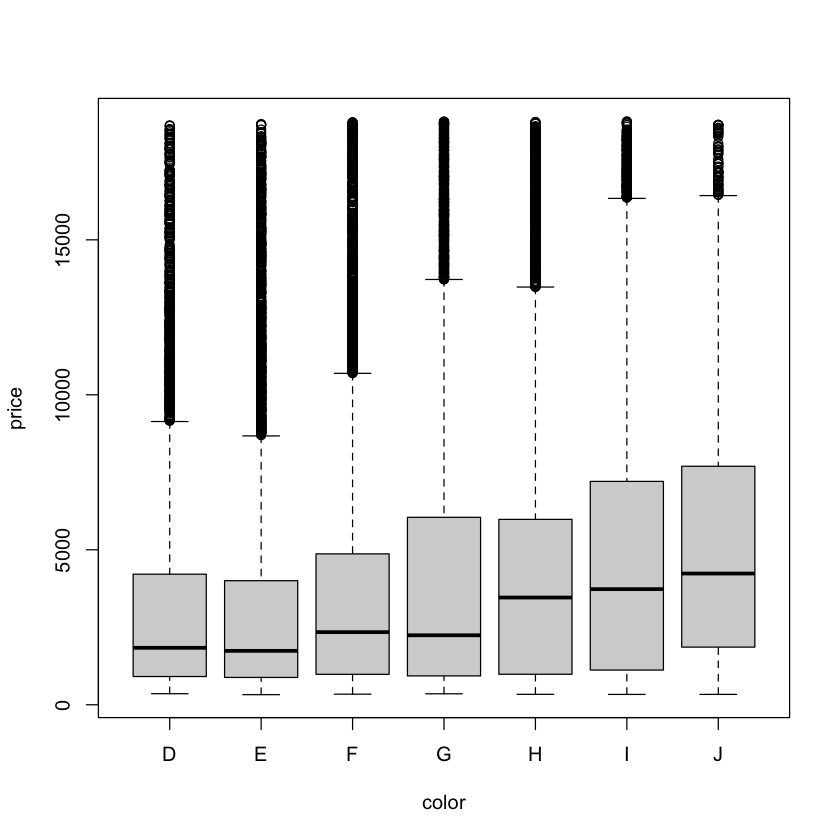

In [24]:
# Multi boxplot: price by color (using tilde notation)
boxplot(price ~ color)

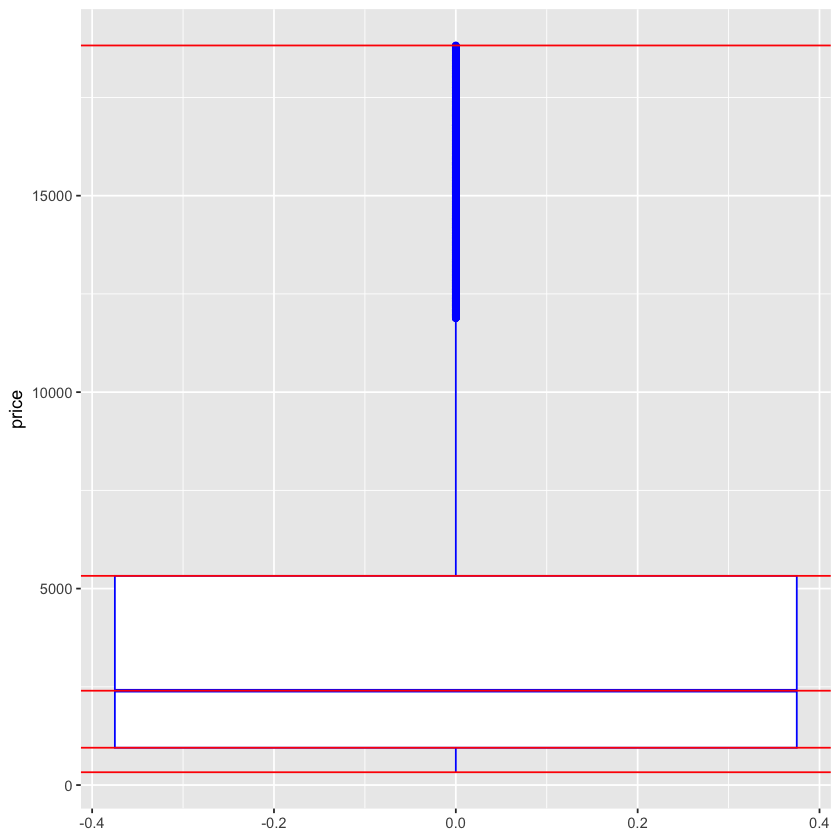

In [26]:
# ggplot2 boxplot (single variable)
ggplot() +
  geom_boxplot(aes(y = price), color = 'blue') +
  geom_hline(yintercept = quantile(price), color = "red")

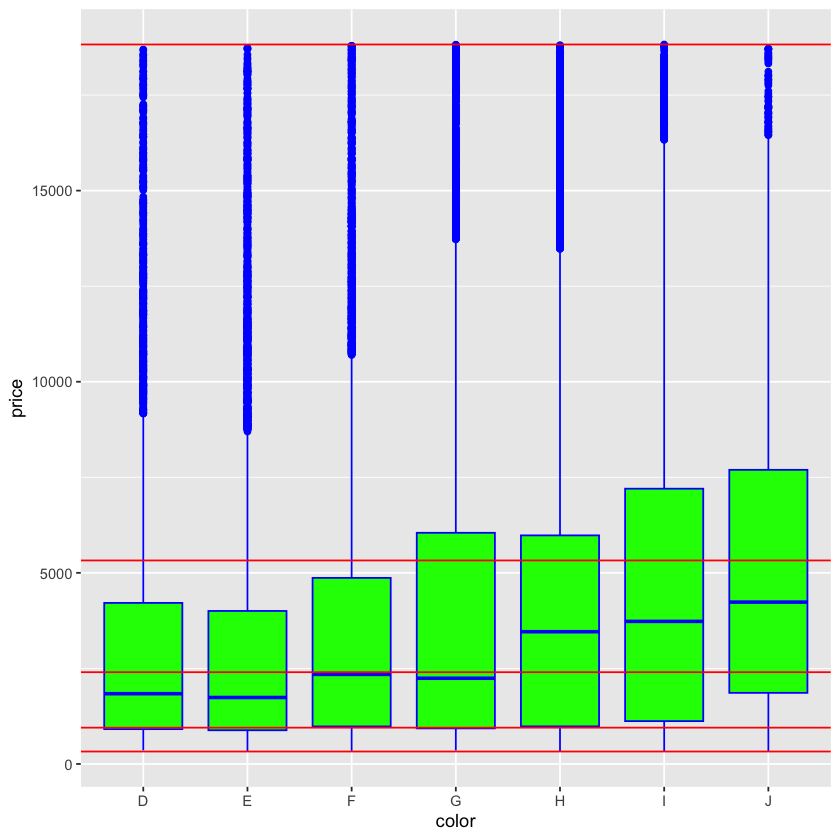

In [27]:
# ggplot2 boxplot by color
ggplot() +
  geom_boxplot(aes(x = color, y = price), color = 'blue', fill = 'green') +
  geom_hline(yintercept = quantile(price), color = "red")

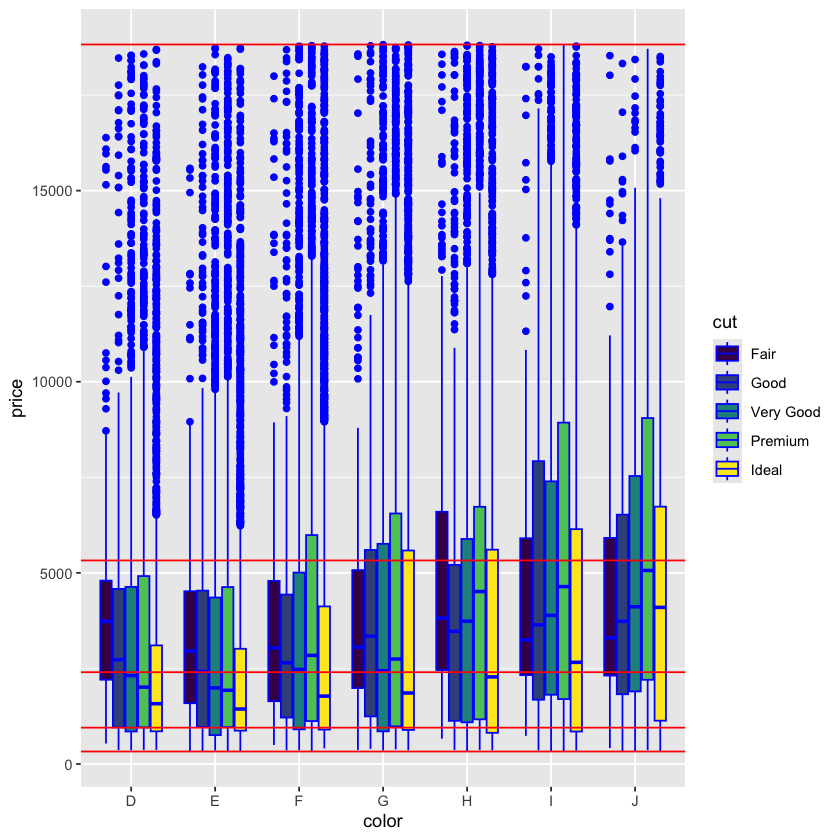

In [28]:
# Multi-group boxplot: price by color, filled by cut
ggplot() +
  geom_boxplot(aes(x = color, y = price, fill = cut), color = 'blue') +
  geom_hline(yintercept = quantile(price), color = "red")

---
## 5. VARIABILITY INDEXES

### 5.1 Variance & Standard Deviation

Variance measures the average squared deviation from the mean.  
Standard deviation is the square root of variance (same unit as the data).

In [29]:
# Manual variance calculation (population formula: divide by n)
mean_price <- mean(price)
n <- length(price)
sigma2 <- sum((price - mean_price)^2) / n
print(paste("Population variance:", sigma2))

sigma <- sqrt(sigma2)
print(paste("Population std dev:", sigma))

[1] "Population variance: 15915334.3625762"
[1] "Population std dev: 3989.4027576288"


In [30]:
# Built-in functions (use n-1 by default — sample formula)
var(price)   # sample variance
sd(price)    # sample standard deviation

[1] 15915629

[1] 3989.44

### 5.2 Histogram

Histograms show the distribution shape of a numeric variable.

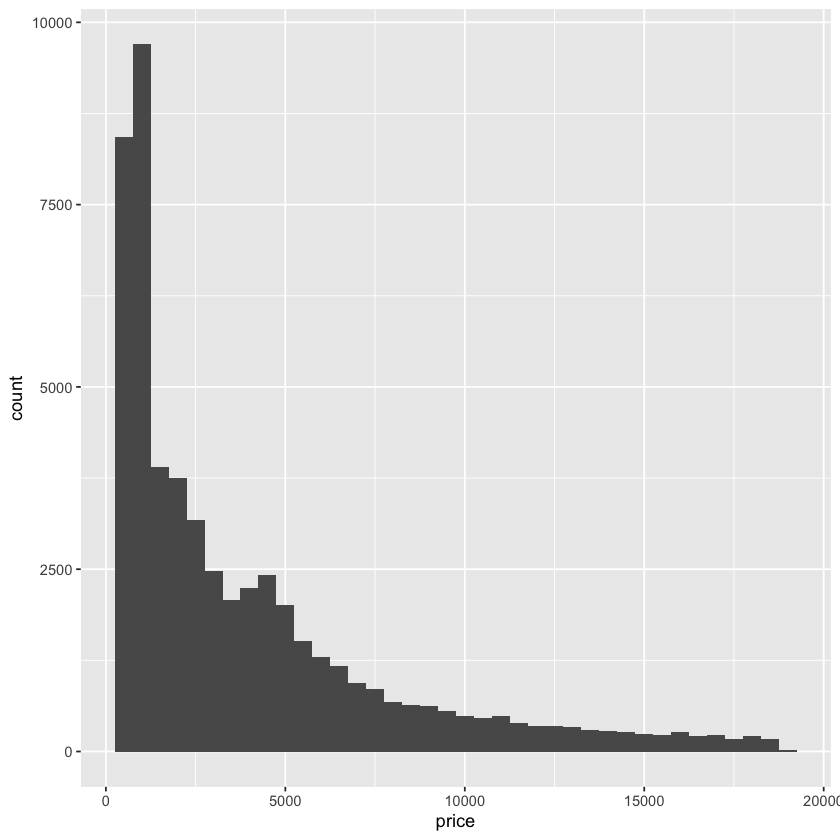

In [31]:
# Histogram of price
ggplot() +
  geom_histogram(aes(x = price), binwidth = 500)

### 5.3 Coefficient of Variation (CV)

CV = (sd / mean) × 100  
It's a **unitless** measure of relative variability, useful for comparing  
variables with different units or scales.

In [32]:
# Define CV function
cv <- function(x) {
    return(sd(x) / mean(x) * 100)
}

# Compare CV of price vs a standardized variable
z <- scale(price)  # standardized (mean=0, sd=1)

print(paste("CV of price:", cv(price)))
print(paste("CV of z:", cv(z)))

[1] "CV of price: 101.440195795314"
[1] "CV of z: -15779588667261990"


### 5.4 Grouped Variability with dplyr

The `dplyr` package provides the `%>%` (pipe) operator for chaining operations.  
Use `group_by()` + `summarise()` to compute statistics by group.

In [33]:
# install.packages("dplyr")
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [34]:
# Group by cut and compute mean, sd, and CV of price
diamonds %>%
  group_by(cut) %>%
  summarise(
    mean_price = mean(price),
    sd_price = sd(price),
    cv_price = cv(price)
  )

cut,mean_price,sd_price,cv_price
<ord>,<dbl>,<dbl>,<dbl>
Fair,4358.758,3560.387,81.68352
Good,3928.864,3681.590,93.70620
Very Good,3981.760,3935.862,98.84730
Premium,4584.258,4349.205,94.87261
Ideal,3457.542,3808.401,110.14765


---
## 6. GINI INDEX

The **Gini index** measures concentration/heterogeneity for categorical variables.  
It ranges from 0 (all observations in one category) to 1 (uniform distribution).

In [35]:
# Define Gini index function (normalized)
giniindex <- function(x) {
    ni <- table(x)
    fi <- ni / length(x)
    fi2 <- fi^2
    J <- length(table(x))

    gini <- 1 / sum(fi2)
    gini.normalized <- gini / ((J - 1) / J)
    return(gini.normalized)
}

In [36]:
# Check distribution of color
table(color)

color
    D     E     F     G     H     I     J 
 6775  9797  9542 11292  8304  5422  2808 

In [37]:
# Compute Gini index for color
giniindex(color)

[1] 7.273598

---
## 7. MAPS

R can plot geographic data using the `mapdata` package.

In [38]:
# Install mapdata if needed
# install.packages("mapdata")
library(mapdata)

# Get Italy map data
italia <- map_data("italy")
str(italia)

Loading required package: maps



'data.frame':	10284 obs. of  6 variables:
 $ long     : num  11.8 11.8 11.7 11.7 11.7 ...
 $ lat      : num  46.5 46.5 46.5 46.5 46.5 ...
 $ group    : num  1 1 1 1 1 1 1 1 1 1 ...
 $ order    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ region   : chr  "Bolzano-Bozen" "Bolzano-Bozen" "Bolzano-Bozen" "Bolzano-Bozen" ...
 $ subregion: chr  NA NA NA NA ...


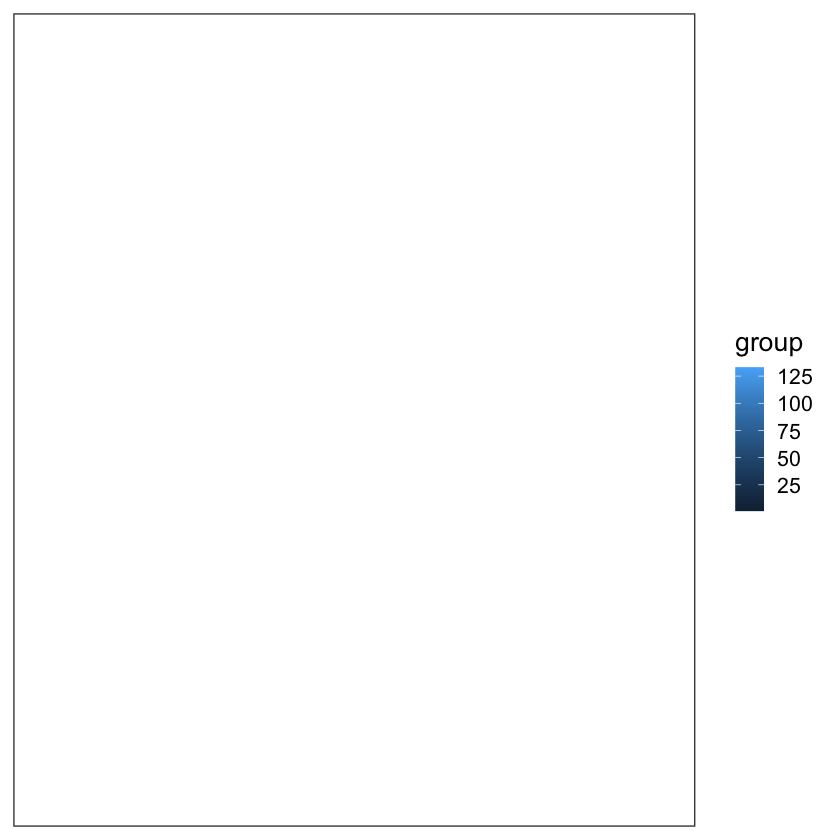

In [39]:
# Plot Italy map
p <- ggplot(data = italia) +
    geom_map(map = italia,
             mapping = aes(map_id = region, fill = group),
             color = "black") +
    scale_x_continuous(breaks = c(7, 18)) +
    scale_y_continuous(breaks = c(37, 47)) +
    theme_bw(base_size = 16)
print(p)

---
## Summary — Part 2

| Concept | Key Functions / Packages |
|---------|------------------------|
| Pie charts | `pie()` |
| Barplots (base) | `barplot()` |
| Bar charts (ggplot2) | `geom_bar()`, `position = "stack"/"dodge"/"fill"` |
| Line plots | `geom_line()`, `geom_point()` |
| Boxplots | `boxplot()`, `geom_boxplot()` |
| Histograms | `geom_histogram()` |
| Scatter plots | `geom_point()` |
| Range / IQR | `range()`, `IQR()`, `quantile()` |
| Variance / SD | `var()`, `sd()`, manual calculation |
| Coefficient of Variation | `cv <- function(x) sd(x)/mean(x)*100` |
| Grouped summaries | `dplyr::group_by()`, `summarise()`, `%>%` |
| Gini index | Custom function using `table()` |
| Maps | `mapdata::map_data()`, `geom_map()` |
| Themes | `theme_classic()`, `theme_bw()`, `labs()` |